In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pwd
# 리눅스 명령어, 현재 작업 중인 디렉토리명 출력

/content


In [3]:
%cd /content/drive/MyDrive/Colab Notebooks/동아3기_텍스트마이닝
# 리눅스 명령어, 작업 위치를 바꾸는 명령어

/content/drive/MyDrive/Colab Notebooks/동아3기_텍스트마이닝


## 네이버 쇼핑 리뷰 데이터 기반으로 임베딩 맛보기

In [4]:
import pandas as pd

In [5]:
data = pd.read_csv("./data/naver_shopping.txt", delimiter = "\t", header = None)
# header = None : 헤더가 없으니 인덱스 번호로 헤더를 잡아주세요

KeyboardInterrupt: 

In [ ]:
data.head(3)

In [ ]:
# 컬럼명 업데이트
data.columns = ["평점", "리뷰"]

In [ ]:
data.head()

In [ ]:
# 리뷰(document)만 인덱싱
text = data["리뷰"]

# 1. 정제
- 1.1 결측치 확인
- 1.2 특수문자 제거

In [ ]:
data.info()
# 결측치 없음 확인

- 1.2 특수문자 제거 → re 활용

In [ ]:
import re

In [ ]:
# r"" : 원시(raw)문자열, \를 하나만 사용 가능하게끔 만듬!
# 이 것이 아닌 데이터를 보겠다(?)
pattern = r'[^a-zA-Z0-9가-힣\s\.\?\!]'

# 알파벳, 숫자, 한글문자, 공백을 제외한 패턴
# 리뷰가 길어지는 경우, 문장 구분을 위해 공백(\s), .?! 보존
# "\s"는 공백 문자를 의미하며, 여기에는 줄바꿈(\n)도 포함됨
# ^ : not (이 것이 아니라면)

In [ ]:
from tqdm.auto import tqdm

In [ ]:
new_doc = []
for doc in tqdm(text) :
    cleaned_doc = re.sub(pattern, "", doc)   # sub() : 이 것이 아니라면 바꾸겠다
    new_doc.append(cleaned_doc)

In [ ]:
# 정제 된 텍스트 데이터 컬럼으로 추가
data["cleaned_doc"] = new_doc

In [ ]:
data.head(3)

# 2. 형태소 분리
- 2.1 형태소 분리, 어간 추출, 정규화, 원하는 품사만 추출, 불용어 제거, 띄어쓰기 교정
- 2.2 DF 추가

In [ ]:
!pip -q install kiwipiepy

In [ ]:
# 불용어 사전 로드
from kiwipiepy.utils import Stopwords

In [ ]:
# 불용어 사전 객체 초기화
stopwords = Stopwords()

In [ ]:
# 불용어 사전의 단어들만 추출
stopwords_list = [word for word, tag in stopwords.stopwords]

In [ ]:
stopwords_list

['되',
 '따르',
 '다고',
 '와',
 '하',
 '없',
 '같',
 '만',
 '에',
 '게',
 '등',
 '지역',
 '며',
 '나',
 '에서',
 '중',
 '기',
 '사람',
 '한',
 '던',
 '들',
 '제',
 '되',
 '과',
 '겠',
 '고',
 'ᆫ',
 '있',
 '통하',
 '다는',
 '월',
 '이',
 '이',
 '부터',
 '그',
 'ᆫ다',
 '우리',
 '일',
 '라',
 '면',
 '성',
 '지',
 '그',
 '를',
 'ᆯ',
 '은',
 '은',
 '어서',
 '로',
 '대하',
 '면서',
 '더',
 '는',
 '않',
 '때',
 '지만',
 '하',
 '말',
 '하',
 '주',
 '어',
 '의',
 '으로',
 '에게',
 '명',
 '일',
 '어',
 '와',
 '어야',
 '화',
 '을',
 '다',
 '가',
 '이',
 '하',
 '다',
 '받',
 '는',
 '있',
 '위하',
 '아니',
 '보',
 '까지',
 '과',
 '라는',
 '이',
 '때문',
 '것',
 '만',
 '적',
 '원',
 '을',
 '고',
 '이',
 '수',
 '도',
 '지',
 '년',
 '었',
 'ᆫ']

In [ ]:
!pip -q install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 24.6 MB/s eta 0:00:00


In [ ]:
# 형태소 분석기 초기화
from konlpy.tag import Okt
okt = Okt()

In [ ]:
# 띄어쓰기 교정용으로 키위분석기 초기화
from kiwipiepy import Kiwi
kiwi = Kiwi()

In [ ]:
kiwi.space("띄어쓰기교정해")

'띄어쓰기 교정해'

In [ ]:
okt.tagset
# Noun, Adjective, Verb

{'Adjective': '형용사',
 'Adverb': '부사',
 'Alpha': '알파벳',
 'Conjunction': '접속사',
 'Determiner': '관형사',
 'Eomi': '어미',
 'Exclamation': '감탄사',
 'Foreign': '외국어, 한자 및 기타기호',
 'Hashtag': '트위터 해쉬태그',
 'Josa': '조사',
 'KoreanParticle': '(ex: ㅋㅋ)',
 'Noun': '명사',
 'Number': '숫자',
 'PreEomi': '선어말어미',
 'Punctuation': '구두점',
 'ScreenName': '트위터 아이디',
 'Suffix': '접미사',
 'Unknown': '미등록어',
 'Verb': '동사'}

In [ ]:
# 사용자 함수 정의하기
def pos_tagging(text) :
    # 1. 띄어쓰기 교정
    text = kiwi.space(text)

    # 2. 품사태깅(형태소 분리)
    pos_wards = okt.pos(
        text,
        stem = True, # 어간추출
        norm = True  # 정규화(표준화)
    )

    # 3. 원하는 품사 추출 (명사, 형용사, 동사)
    tagged_list = []

    for word, tag in pos_wards :
        if tag in ["Noun", "Adjective", "Verb"] : # 명사, 형용사, 동사인가?
            if word not in stopwords_list : # 불용어 사전에 해당되지 않는가?
                tagged_list.append(word)
    return tagged_list

In [ ]:
# 함수 테스트
pos_tagging(data["cleaned_doc"].iloc[0])
# 오탈자는 사람이 수정 해야함

['배', '공', '빠르다', '굿']

In [ ]:
# 약 25분 소요

# 함수 적용
tagged_doc = []

for text in tqdm(data["cleaned_doc"]) : # 모든 리뷰들을 순회
    tagged_doc.append(pos_tagging(text)) # 형태소 분리 및 전처리 된 text들

  0%|          | 0/200000 [00:00<?, ?it/s]

- 2.2 DF 추가 및 저장

In [ ]:
# df에 추가
data["tagged_doc"] = tagged_doc

In [ ]:
import pickle

with open("./data/naver_shopping(정제 및 토큰화 완료).pkl", "wb") as f :
    pickle.dump(data, f)

# 텍스트 마이닝 팁!
# 자료를 전처리하는데 있어서 시간이 오래걸림
# 자료 전처리가 끝난 것은 파일화 시켜서 동일한 작업을 두번하지 않는 것이 시간을 아끼는 방법
# 파일 저장을 꼼꼼하게 해주는 것이 중요함

# 정제 및 토큰화 완료!
- 다음 실습부턴 아래부터 실행!

In [1]:
# 드라이브 마운트
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pwd
# 리눅스 명령어, 현재 작업 중인 디렉토리명 출력

/content


In [3]:
%cd /content/drive/MyDrive/Colab Notebooks/동아3기_텍스트마이닝
# 리눅스 명령어, 작업 위치를 바꾸는 명령어

/content/drive/MyDrive/Colab Notebooks/동아3기_텍스트마이닝


In [6]:
# gensim : 단어 임베딩(word2vec)를 가지고 있는 라이브러리
# 기존에 TF-IDF / CountVectorize 같은 경우 문맥의 의미를 반영하지 못함
# word2vec : 기존 단어가방보다 고도화 된 기술로 문맥을 반영해서 수치화 변환해주는 라이브러리
#  => 의미를 보고 수치화를 진행
#    ex) TF-IDF : 사과 / 배 => 숫자를 지정했을때 빈도 수만 보고 판단 사과 / 배의 관계는 표시되지 않음
#    ex) word2vec : 사과 기준 확인 / 배 기준 확인 => 별도로 점수를 매김 => 비슷한지 아닌지를 판별하는 구조
#   word2vec을 사용하는 경우 단거안의 유사도 분석을 진행 할 수 있음(각도 기반의 코사인 유사도를 판별)
#    => 0˚ 의미가 같음 = 1
#    => 180˚ 반대의 의미를 가짐 = -1
#    => 90˚ 의미 관계 없음 = 0
!pip -q install --upgrade gensim

# 나눔 폰트(fonts-nanum)를 시스템에 설치
# '-y' 옵션은 설치 시 사용자에게 확인을 요구하지 않고 자동으로 진행되도록 함
!apt-get install -y fonts-nanum*

# 설치된 폰트를 시스템 폰트 캐시에 등록함
# 'fc-cache -fv' 명령은 폰트 캐시를 강제로 새로고침
!sudo fc-cache -fv

# Matplotlib의 캐시를 삭제
# '~/.cache/matplotlib' 폴더에 저장된 캐시 파일들을 모두 제거
# 이 과정은 새로운 폰트가 적용되지 않는 문제를 해결하는 데 유용
!rm ~/.cache/matplotlib -rf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.6 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
The following NEW packages will be installed:
  fonts-nanum fonts-nanum-coding fonts-nanum-eco fonts-nanum-extra
0 upgraded, 4 newly installed, 0 to remove and 37 not upgraded.
Need to get 46.0 MB of archives.
After this operation, 177 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-coding all 2.5-3 [4,988 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-eco all 1.000-7 [14.7 MB]
Get:4 http://archiv

In [4]:
import pandas as pd
import pickle
from tqdm.auto import tqdm

with open("./data/naver_shopping(정제 및 토큰화 완료).pkl", "rb") as f :
    data = pickle.load(f)

In [7]:
data

,평점,리뷰,cleaned_doc,tagged_doc
0,5,배공빠르고 굿,배공빠르고 굿,"[배, 공, 빠르다, 굿]"
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[택배, 엉망, 용, 저희, 집, 밑, 층, 놔두다, 가다]"
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[아주, 좋다, 바지, 정말, 좋다, 개, 구매, 하다, 가격, 대박, 이다, 바느..."
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[선물, 용, 받다, 전달, 하다, 하다, 상품, 이다, 머그, 컵, 오다, 당황,..."
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요,"[민트, 색상, 예쁘다, 옆, 손잡이, 거, 용, 도로, 사용, 되다]"
...,...,...,...,...
199995,2,장마라그런가!!! 달지않아요,장마라그런가!!! 달지않아요,"[장마, 런가, 달, 않다]"
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,"[다이슨, 케이스, 구매, 하다, 다이슨, 슈퍼, 소닉, 드라이기, 케이스, 구매,..."
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요,로드샾에서 사는것보다 세배 저렴하네요 자주이용할께요,"[로드샾, 살다, 세, 배, 저렴하다, 자주, 이용, 하다]"
199998,5,넘이쁘고 쎄련되보이네요~,넘이쁘고 쎄련되보이네요,"[넘다, 이쁘다, 쎄다, 되다, 보이다]"


## Word2Vec
- 단어 임베딩 방법론(모델) 중 하나
- https://word2vec.kr/search/

> 두 가지 방법
> - CBOW : 주변에 있는 단어들을 입력으로 중간에 있는 단어들을 학습/예측하는 방법
> - Skip-gram : 중간에 있는 단어들을 입력으로 주변 단어들을 학습/예측하는 방법


### Word2Vec 사전학습 모델로 테스트해보기

`API 로드가 오래걸리니까 코드 먼저 쳐서 실행시켜놓고, 설명하셈`

## 유사도 계산
- 유사도(Similarity) : 비슷한 정도

> 1. Euclidean Distance(유클리디안 거리)
> 2. Cosine Similarity(코사인 유사도)
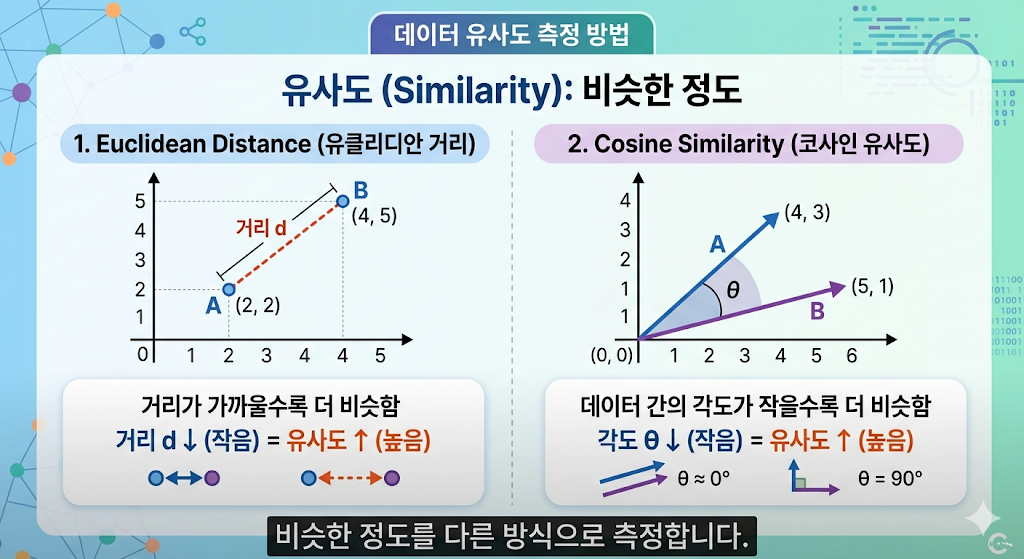
> - 유클리디안 거리에서는 `거리가 가까울 수록`, 코사인 유사도에서는 `각 데이터 간의 각도가 작을 수록` 데이터가 비슷하다는 것을 의미

$ similarity=cos(Θ)=\frac{A⋅B}{||A||\ ||B||}=\frac{\sum_{i=1}^{n}{A_{i}×B_{i}}}{\sqrt{\sum_{i=1}^{n}(A_{i})^2}×\sqrt{\sum_{i=1}^{n}(B_{i})^2}} $

> **분자(위쪽 식):**  
> - $(A \cdot B)$ : 두 벡터의 내적(점곱)  
> - $(\sum_{i=1}^n A_i \times B_i$) 형태로 각 차원별 곱을 모두 더한 값  

> **분모(아래쪽 식):**  
> - $(\|A\|$)와 $(\|B\|$)는 각각 벡터 $(A$)와 $(B$)의 크기(노름, norm)  
> - $(\sqrt{\sum_{i=1}^n (A_i)^2}$)와 $(\sqrt{\sum_{i=1}^n (B_i)^2}$)로 계산  

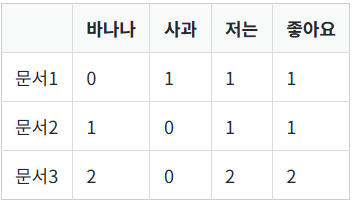

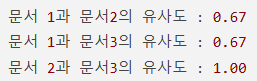

In [8]:
# word2vec 모델(사전학습모델)을 활용한 임베딩 개념 이해해보기!
import gensim.downloader as api
# gensim : 복잡한 설치 없이 간단한 api 호출로 사전 학습 된 워드 임베딩 모델 제공

```python
# 'api.info()' 메서드를 통해 모델들의 정보를 가져와서
# 'models'라는 키 아래에 있는 항목들을 정렬하여 반복
for model_name, model_data in sorted(api.info()['models'].items()):

    # 각 모델의 데이터에서 'num_records' 키에 해당하는 값이 있으면 사용, 없으면 기본값 -1을 사용
    num_records = model_data.get('num_records', -1)

    # 각 모델의 설명을 40자까지만 잘라서 표시하고 그 뒤에 '...'을 추가
    description = model_data['description'][:40] + '...'

    # 각 모델의 이름, 레코드 수, 그리고 잘린 설명을 출력
    print(f"{model_name} ({num_records} records): {description}")
```

In [9]:
# 사용 가능한 여러 모델 리스트업
for model_name, model_data in sorted(api.info()['models'].items()):
    num_records = model_data.get('num_records', -1)
    description = model_data['description'][:40] + '...'

    print(f"{model_name} ({num_records} records): {description}")

__testing_word2vec-matrix-synopsis (-1 records): [THIS IS ONLY FOR TESTING] Word vecrors ...
conceptnet-numberbatch-17-06-300 (1917247 records): ConceptNet Numberbatch consists of state...
fasttext-wiki-news-subwords-300 (999999 records): 1 million word vectors trained on Wikipe...
glove-twitter-100 (1193514 records): Pre-trained vectors based on  2B tweets,...
glove-twitter-200 (1193514 records): Pre-trained vectors based on 2B tweets, ...
glove-twitter-25 (1193514 records): Pre-trained vectors based on 2B tweets, ...
glove-twitter-50 (1193514 records): Pre-trained vectors based on 2B tweets, ...
glove-wiki-gigaword-100 (400000 records): Pre-trained vectors based on Wikipedia 2...
glove-wiki-gigaword-200 (400000 records): Pre-trained vectors based on Wikipedia 2...
glove-wiki-gigaword-300 (400000 records): Pre-trained vectors based on Wikipedia 2...
glove-wiki-gigaword-50 (400000 records): Pre-trained vectors based on Wikipedia 2...
word2vec-google-news-300 (3000000 records): Pre-trai

- Records : 레코드의 수, 즉 데이터의 개수를 의미(각 "레코드"는 임베딩된 단어 하나를 의미)

| 모델 이름                           | 레코드 수      | 설명                                                                                                  |
|-------------------------------------|----------------|-------------------------------------------------------------------------------------------------------|
| conceptnet-numberbatch-17-06-300    | 1,917,247      | ConceptNet Numberbatch는 개념 간의 관계를 학습한 모델.                                                 |
|                                     |                | 상식을 이해하고 개념 간 관계를 연결시키기 위해 개발됨.                                                 |
|                                     |                | 주로 의미 네트워크 연구에 사용됨. "고양이"와 "동물" 간의 관계를 학습.                                  |
| fasttext-wiki-news-subwords-300     | 999,999        | fastText는 단어뿐만 아니라 서브워드(단어의 작은 부분)를 학습.                                          |
|                                     |                | "unbelievable"을 "un", "believe", "able"로 나누어 학습.                                                 |
|                                     |                | Wikipedia와 뉴스 기사 데이터를 기반으로 학습됨.                                                       |
| glove-twitter-100                   | 1,193,514      | GloVe는 Stanford에서 개발된 모델로, 단어 간의 공간적 관계를 벡터로 표현.                               |
|                                     |                | 트위터 데이터(2억 개 트윗)로 학습되어 소셜 미디어 자연어 처리 작업에 적합.                             |
| word2vec-google-news-300            | 3,000,000      | Word2Vec은 구글 뉴스 데이터로 학습된 모델.                                                             |
|                                     |                | 뉴스 기사의 단어 간 유사성 및 의미적 관계를 잘 포착.                                                   |
|                                     |                | 뉴스 데이터 기반이기 때문에 자연어 처리에 많이 사용됨.                                                 |
| word2vec-ruscorpora-300             | 184,973        | Word2Vec ruscorpora는 러시아어 텍스트 기반의 모델로,                                                   |
|                                     |                | 러시아어 자연어 처리 작업에 사용됨.                                                                   |


In [10]:
# 여러 모델이 제공됨
# 이 중에서 word2vec-google-news-300 모델 로드하기
model = api.load("word2vec-google-news-300")
# 구글 뉴스 데이터로 훈련된 Word2Vec 모델
# 3백만 개의 단어 벡터를 포함하고 있으며, 각 단어는 300차원 벡터로 표현

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [11]:
# "cat" 단어의 임베딩 벡터를 가져옴
cat_vector = model['cat']
cat_vector
# "cat"이라는 단어에 대응하는 300차원 벡터가 출력

array([ 0.0123291 ,  0.20410156, -0.28515625,  0.21679688,  0.11816406,
        0.08300781,  0.04980469, -0.00952148,  0.22070312, -0.12597656,
        0.08056641, -0.5859375 , -0.00445557, -0.296875  , -0.01312256,
       -0.08349609,  0.05053711,  0.15136719, -0.44921875, -0.0135498 ,
        0.21484375, -0.14746094,  0.22460938, -0.125     , -0.09716797,
        0.24902344, -0.2890625 ,  0.36523438,  0.41210938, -0.0859375 ,
       -0.07861328, -0.19726562, -0.09082031, -0.14160156, -0.10253906,
        0.13085938, -0.00346375,  0.07226562,  0.04418945,  0.34570312,
        0.07470703, -0.11230469,  0.06738281,  0.11230469,  0.01977539,
       -0.12353516,  0.20996094, -0.07226562, -0.02783203,  0.05541992,
       -0.33398438,  0.08544922,  0.34375   ,  0.13964844,  0.04931641,
       -0.13476562,  0.16308594, -0.37304688,  0.39648438,  0.10693359,
        0.22167969,  0.21289062, -0.08984375,  0.20703125,  0.08935547,
       -0.08251953,  0.05957031,  0.10205078, -0.19238281, -0.09

In [12]:
# 유사도를 계산하여, 주어진 단어와 벡터 공간상에서 가장 가까운 단어들을 나열
# 기본 코사인 유사도 점수 (-1 ~ 1 사이의 값, 벡터가 동일한 방향일수록 값은 1에 가까워지고, 반대 방향일수록 값은 -1에 가까워집)
model.most_similar("cat")

[('cats', 0.8099379539489746),
 ('dog', 0.760945737361908),
 ('kitten', 0.7464985251426697),
 ('feline', 0.7326234579086304),
 ('beagle', 0.7150582671165466),
 ('puppy', 0.7075453400611877),
 ('pup', 0.6934291124343872),
 ('pet', 0.6891531348228455),
 ('felines', 0.6755931973457336),
 ('chihuahua', 0.6709762215614319)]

- -1 이상 1 이하의 값을 가지며 값이 1에 가까울수록 유사도가 높다고 판단
- 두 벡터가 가리키는 방향이 얼마나 유사한가를 의미

<img src = "https://wikidocs.net/images/page/24603/%EC%BD%94%EC%82%AC%EC%9D%B8%EC%9C%A0%EC%82%AC%EB%8F%84.PNG"/>



> **결과 해석:**  
> - 두 벡터가 완전히 동일한 방향이면(각도 $(\theta = 0$)) 유사도는 1  
> - 두 벡터가 서로 직교(각도 $(90^\circ$))하면 유사도는 0  
> - 두 벡터가 반대 방향이면(각도 $(\theta = 180^\circ$)) 유사도는 -1  
> - **문서 유사도 계산** 시 보통 음수 값은 잘 안 나오므로(벡터가 음수값을 가질 때 제외), 0에 가까울수록 유사도가 낮고 1에 가까울수록 유사도가 높다고 해석함  


In [13]:
# most_similar_cosmul() : 단어 임베딩 벡터 간의 유사도 계산 후, 가장 유사한 단어들을 반환하는 함수
# cosmul 방식 : 벡터들의 코사인 유사도를 곱셈적으로 결합하여 결과를 산출함

print(model.most_similar_cosmul(positive=['soju','mexico'], negative=['korea']))
# 1. 'soju'와 'mexico'의 임베딩 벡터를 더함
# 2. 'korea'의 임베딩 벡터를 빼줌
# 3. 계산된 결과 벡터와 다른 단어들의 임베딩 벡터들 간의 코사인 유사도를 곱셈 방식으로 결합하여 최종 유사도를 산출
# 4. 최종 유사도가 높은 단어들을 리스트 형태로 반환 및 출력

print(model.most_similar_cosmul(positive=['soju','russia'], negative=['korea']))

[('tequila', 0.8992794156074524), ('mezcal', 0.8555493950843811), ('agave_tequila', 0.8524277806282043), ('Modelo_Especial', 0.836313784122467), ('pulque', 0.8301872611045837), ('mescal', 0.8242558240890503), ('distilled_liquor', 0.8173635601997375), ('Agavero', 0.8148321509361267), ('rum', 0.8130227327346802), ('michelada', 0.8111985325813293)]
[('vodka', 0.8616750240325928), ('brandy', 0.8266340494155884), ('distilled_liquor', 0.8266003727912903), ('Ochakovo', 0.8215005397796631), ('Campari', 0.8179371953010559), ('brandy_cognac', 0.8096943497657776), ('Bombay_Sapphire_gin', 0.8087176084518433), ('plum_brandy', 0.8080827593803406), ('Spanish_cava', 0.8054169416427612), ('whiskey_brandy', 0.8039817214012146)]


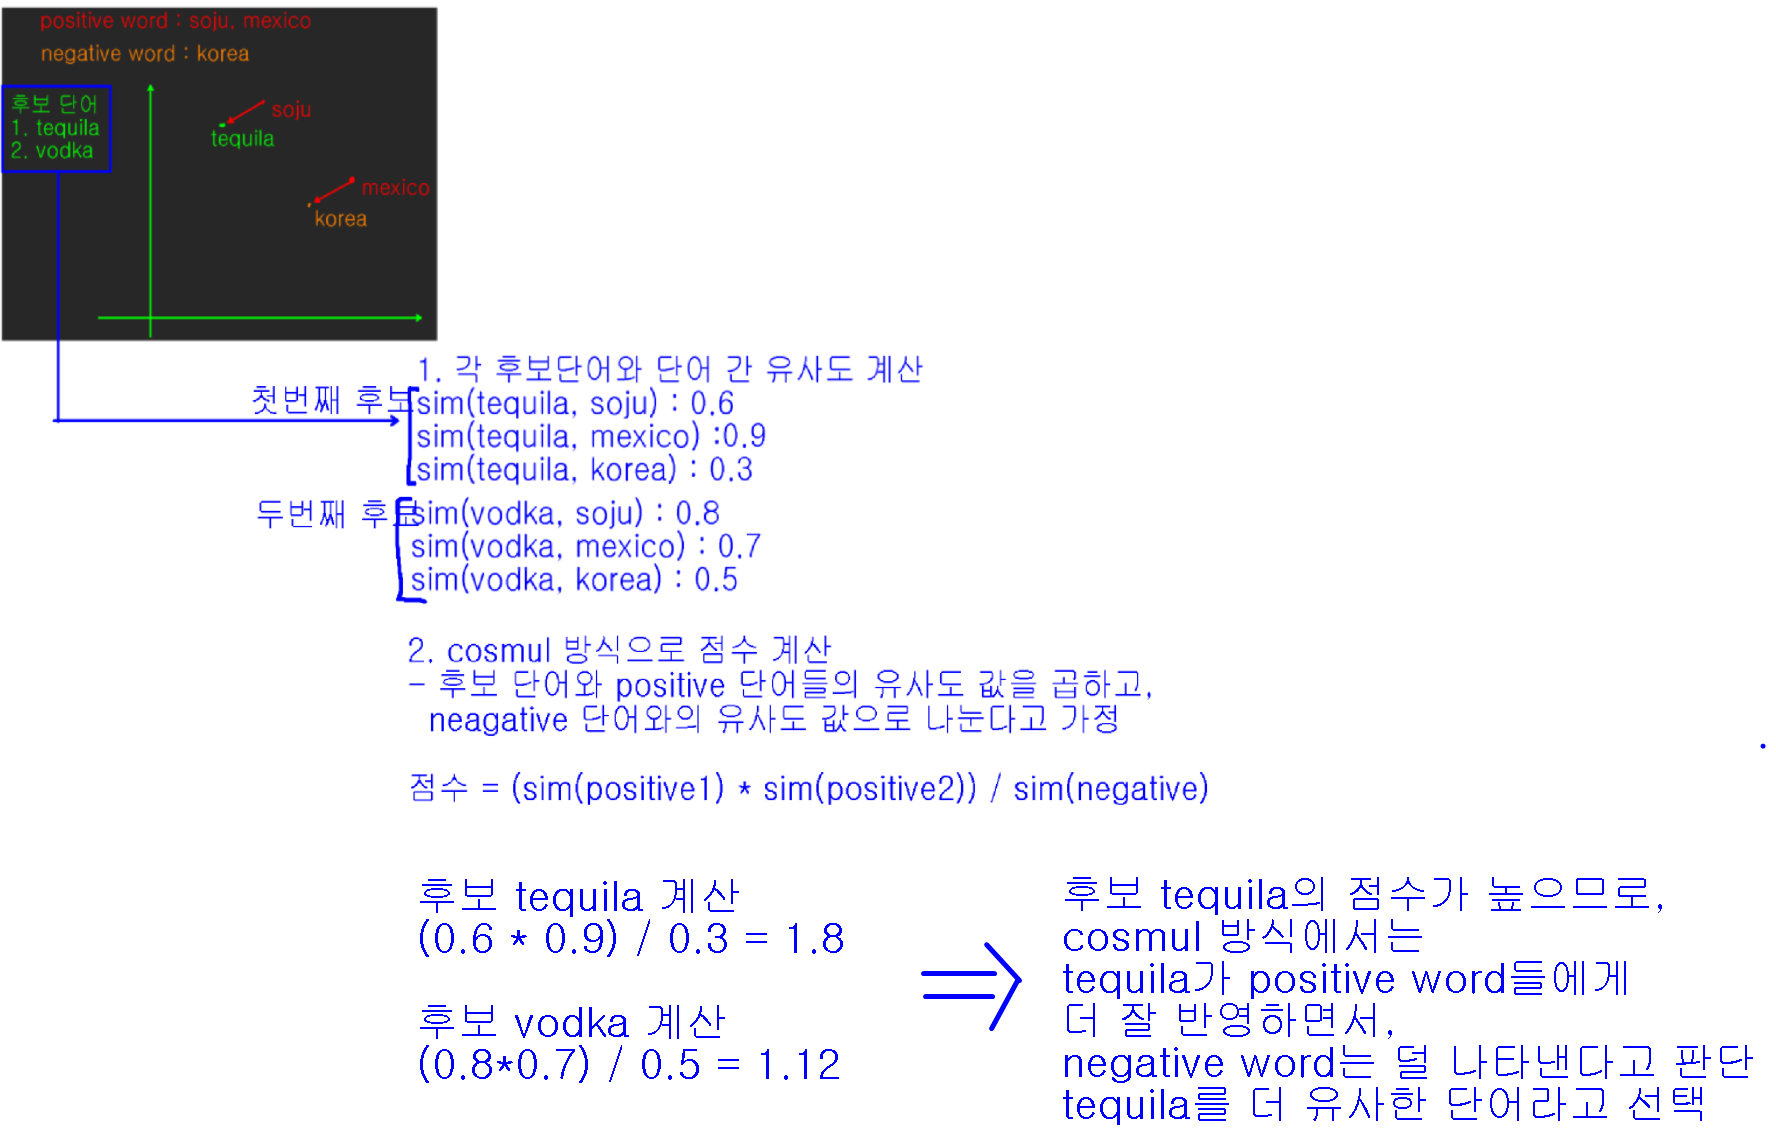

- **주의 사항**  
  - 실제 `most_similar_cosmul()` 내부 계산은 위 예시처럼 단순 곱셈/나눗셈이 아닌, 코사인 유사도를 기반으로 한 복잡한 연산을 수행함  
  - 여기서는 이해를 돕기 위한 간단화된 예시로 생각하면 됨
  - $ \text{score} = \frac{\prod (\text{sim}(\text{candidate}, \text{positive}_i))}{\prod (\text{sim}(\text{candidate}, \text{negative}_j))}$

#### Word2Vec 직접 학습
- 단어의 본질적인 의미를 파악할 수 있도록 수치화를 정교하게 해보자

---

##### 보통 Skip-gram 방식 + Narative Sampling 방법이 CBOW보다 임베딩 품질이 좋은 경향이 있음

- Skip-gram은 같은 Corpus로도 더 많은 학습 데이터를 확보할 수 있기 때문에 단어 임베딩의 품질이 좋음
> 그런데 Skip-Gram의 경우 모든 문맥 단어 쌍을 학습하는데, 계산 비용이 큼
> - Nagative Sampling(SGNS, Skip-gram with Negative Sampling)
> - Skip-gram 모델에서 효율적으로 학습을 진행하기 위해 사용하는 샘플링 기법

In [14]:
from gensim.models import Word2Vec
# Word2Vec 클래스(주의 : 학습이 안 되어 있음)

In [15]:
data["tagged_doc"]   # 학습용 데이터로 사용

,tagged_doc
0,"[배, 공, 빠르다, 굿]"
1,"[택배, 엉망, 용, 저희, 집, 밑, 층, 놔두다, 가다]"
2,"[아주, 좋다, 바지, 정말, 좋다, 개, 구매, 하다, 가격, 대박, 이다, 바느..."
3,"[선물, 용, 받다, 전달, 하다, 하다, 상품, 이다, 머그, 컵, 오다, 당황,..."
4,"[민트, 색상, 예쁘다, 옆, 손잡이, 거, 용, 도로, 사용, 되다]"
...,...
199995,"[장마, 런가, 달, 않다]"
199996,"[다이슨, 케이스, 구매, 하다, 다이슨, 슈퍼, 소닉, 드라이기, 케이스, 구매,..."
199997,"[로드샾, 살다, 세, 배, 저렴하다, 자주, 이용, 하다]"
199998,"[넘다, 이쁘다, 쎄다, 되다, 보이다]"


In [16]:
# Word2Vec 모델을 생성하고, 주어진 데이터셋으로 학습 (SGNS 사용)
# Skip-Gram - Negative Sampling
w2v = Word2Vec(
    window = 3,            # 한 단어와 관련된 인접한 단어의 범위를 지정 (window 크기)
    min_count = 5,         # 특정 단어가 학습에 포함되기 위한 최소 등장 횟수 (5회 미만 단어는 제외)
    sg = 1,                # Skip-gram 모델 사용 (sg=1), 만약 0이면 CBOW 모델 사용 (1=True, 0=False)
    vector_size = 100,     # 각 단어를 임베딩할 벡터의 차원 수 (100차원의 벡터로 표현)
    negative = 5,          # Negative Sampling 사용, 음성 샘플링 개수 (5개의 단어 샘플링) (긍정(1)+부정(5))
    sentences = data["tagged_doc"] # 학습에 사용할 문장 데이터가 담긴 데이터셋
)

# negative sample : 목표 단어가 아닌 무작위 단어(음성 샘플)를 선택해 추가 학습
# 일반적으로 5나 10 정도로 설정

In [17]:
# "배송"이라는 단어에 대한 임베딩 벡터를 확인
w2v.wv.get_vector("배송")
# 배송이라는 단어가 입력 되었을 때 이 단어가 100차원의 공간에서 어디에 위치하고 있는지 밀집 벡터 형태로 결과를 제공
# 배송이라는 단어와 연관이 있는 단어는 뭐가 있을까?(배달 / 운송 / 택배 / 지연 등...)
# 주의점 : KeyError : "word '배송' not in vocabulary" 에러가 발생 할 수 있음
# 이 내용은 빈도수가 모자라서 학습에서 제외 되었을 가능성이 높다
# 배송에 태그가 붙어서 배송 /Noun 형식으로 데이터가 학습 되었을 가능성이 있다
# 데이터 꼭! 확인해보기

# wv : word vectors

array([-0.31904617,  0.20503505, -0.23625654, -0.33369502, -0.46373245,
       -0.01766549, -0.08708168,  0.4372314 , -0.51723963, -0.24761589,
       -0.437927  , -0.35874477, -0.41776   , -0.31092945, -0.03967264,
       -0.51924884, -0.1552615 , -0.45378426,  0.04953765, -0.13244379,
       -0.16230202, -0.33975697,  0.33163115,  0.32675076, -0.22913912,
       -0.04074898, -0.08143838, -0.02708235, -0.16106097,  0.6612405 ,
        0.616213  , -0.32674226,  0.15840846, -0.73563987, -0.23636033,
        0.34852615,  0.6559459 , -0.03612518, -0.11487722, -0.17167273,
        0.26391762, -0.45246723, -0.395674  ,  0.05852546,  0.13669764,
        0.02637069, -0.30662268, -0.4285197 ,  0.11594374, -0.00240124,
        0.11843388, -0.76182103,  0.39228678,  0.2189546 , -0.49383274,
       -0.14131294,  0.72259915, -0.17909625, -0.5727222 , -0.05490551,
        0.21679775, -0.16545705,  0.32660362, -0.7424271 , -0.2518445 ,
        0.10692561,  0.29117632,  0.35921285, -0.32584926, -0.00

In [65]:
# "만족"과 유사한 단어들을 20개 확인 (코사인 유사도 기준으로 상위 20개)
w2v.wv.most_similar("별로", topn = 20)

[('루', 0.80731201171875),
 ('별루', 0.7950661182403564),
 ('벼로', 0.6807568669319153),
 ('별롭니', 0.6720868349075317),
 ('꽝', 0.6713916659355164),
 ('그닥', 0.66707843542099),
 ('루고', 0.6471846103668213),
 ('닥', 0.6360949277877808),
 ('구림', 0.6107556223869324),
 ('비추다', 0.6107333898544312),
 ('의견', 0.6017680764198303),
 ('이상하', 0.5998908877372742),
 ('주관', 0.5969580411911011),
 ('솔직하다', 0.583195149898529),
 ('글쎄요', 0.5829058289527893),
 ('별루임', 0.5827130675315857),
 ('조악하다', 0.5787323117256165),
 ('최악', 0.5780530571937561),
 ('꽃송이', 0.5756426453590393),
 ('가형', 0.5740752220153809)]

In [19]:
data["평점"].value_counts()

,count
평점,
5,81177
2,63989
1,36048
4,18786


# 평점을 기반으로 긍/부정 분류기 + 가중치 분석
1. 평점 기반으로 라벨 생성(4와 5인 경우 긍정 1, 그 외 부정 0)
2. 각 리뷰에 대한 평균 벡터 계산
3. 로지스틱 회귀 모델링
4. 가중치 시각화

- 1. 평점 기반으로 라벨 생성(4와 5인 경우 긍정 1, 그 외 부정 0)


In [20]:
label = []
for rating in data["평점"] :
    if rating > 3 : # 3보다 큰가? / 4점, 5점만 뽑아오겠다
        label.append(1) # 긍정(1)
    else :
        label.append(0) # 부정(0)

In [21]:
data["label"] = label

In [22]:
data.head()

,평점,리뷰,cleaned_doc,tagged_doc,label
0,5,배공빠르고 굿,배공빠르고 굿,"[배, 공, 빠르다, 굿]",1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[택배, 엉망, 용, 저희, 집, 밑, 층, 놔두다, 가다]",0
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[아주, 좋다, 바지, 정말, 좋다, 개, 구매, 하다, 가격, 대박, 이다, 바느...",1
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[선물, 용, 받다, 전달, 하다, 하다, 상품, 이다, 머그, 컵, 오다, 당황,...",0
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요,"[민트, 색상, 예쁘다, 옆, 손잡이, 거, 용, 도로, 사용, 되다]",1


- 2. 각 리뷰에 대한 평균 벡터 계산


In [23]:
# 벡터의 차원 추출
vector_size = w2v.vector_size

In [66]:
vector_size

100

In [67]:
# 각 리뷰의 평균 벡터값을 담아둘 리스트
X_w2v_list = []

In [25]:
w2v.wv

In [26]:
import numpy as np

In [74]:
# 평균 벡터 계산해보기
for doc in data["tagged_doc"] :
    vecs = [] # 해당 리뷰의 각 벡터값들을 담아둘 리스트

    for token in doc : # 각 문장의 토큰에 대해 순회
        if token in w2v.wv : # Word2Vec에 해당 토큰이 들어있니? 학습이 되어있나요?
                                # 학습이 안되어 있다면 vector 값이 없기 때문에 걸러내겠다
            vecs.append(w2v.wv[token]) # 벡터 추가

    if len(vecs) > 0: # 벡터들의 길이값이 0보다 큰가? -> 정제하는 과정에서 없어질 수도 있음!
        avg_vec = np.mean(vecs, axis = 0) # 각 차원별로 평균 계산
    else : # 벡터들의 길이가 없는경우 -> 정제하는 과정에서 삭제된 경우!
        avg_vec = np.zeros(vector_size)

    X_w2v_list.append(avg_vec)

In [75]:
data.shape

(200000, 5)

In [76]:
len(X_w2v_list)

200000

- 3. 로지스틱 회귀 모델링


In [78]:
X_w2v_list[0].ndim   # 몇 차원인지 확인
# 선형 모델에 데이터를 넣어줄때는 2차원 데이터가 필요 => 2차원 데이터 변환

1

In [79]:
X_w2v_list

[array([-0.25875685,  0.06095591, -0.04752877, -0.19180125,  0.17041983,
        -0.31723583,  0.17389452,  0.13455817, -0.4145673 , -0.15373683,
        -0.07398728, -0.2689299 , -0.26017478,  0.06970006,  0.15669797,
         0.01390491,  0.11195548,  0.05147264, -0.18165627, -0.24961297,
         0.09106806,  0.05053719,  0.35859317,  0.20473322, -0.05914164,
        -0.03192961, -0.06669279,  0.05283278, -0.18052588,  0.15395659,
         0.48172897, -0.03484353,  0.04871587, -0.45655668,  0.03804911,
         0.29612464,  0.12690702, -0.17334923, -0.1804587 , -0.42287877,
         0.11115815, -0.02651815, -0.18061912,  0.26235092,  0.21879184,
        -0.22835533, -0.14257549, -0.28050295,  0.02287045,  0.00123622,
         0.07172304, -0.35357437,  0.27337492,  0.14090371, -0.09203451,
        -0.13673829,  0.20492843, -0.01904236, -0.22450387,  0.12945977,
        -0.00817515,  0.41913056,  0.07389028,  0.13617465, -0.15744835,
         0.00089866,  0.4404168 ,  0.1806716 , -0.4

In [29]:
# 리스트를 2차원 array 형변환
X_w2v = np.vstack(X_w2v_list)

In [30]:
X_w2v.shape
# 행 : 데이터 개수
# 열 : 벡터 차원

(200000, 100)

In [80]:
# 교차검증 확인
from sklearn.model_selection import cross_val_score, StratifiedKFold # 교차검증 도구
from sklearn.linear_model import LogisticRegression   # LogisticRegression (이진 분류)

In [32]:
# StratifiedKFold : 교차 검증 시 각 데이터셋의 라벨 비율을 동일하게 유지
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 2025)

logi = LogisticRegression(max_iter = 10000, random_state = 2025)

scores = cross_val_score(logi, X_w2v, data["label"], cv = cv)

In [33]:
display(scores)
display(scores.mean())

array([0.873275, 0.874425, 0.8728  , 0.8718  , 0.874275])

np.float64(0.8733150000000001)

- 4. 가중치 시각화

In [34]:
# 전체 데이터로 모델을 학습하여, 각 Word2Vec 차원에 대한 가중치(계수)를 얻음
logi.fit(X_w2v, data['label'])

LogisticRegression(max_iter=10000, random_state=2025)

In [35]:
coef_vector = logi.coef_[0]  # 로지스틱 회귀 모델의 계수
coef_vector.shape # vector_size

(100,)

##### 감정 기여도 계산하기
- 각 단어가 감성 분류에 얼마나 기여하는지, 수치로 표현해보자
> 벡터간 내적 계산 활용
> - 단어 임베딩 벡터
> - 로지스틱 회귀모델 계수 벡터


In [36]:
# 데이터 내에 등장하는 단어 집합 생성 (w2v에 존재하는 단어만 고려)
# 집합의 종류 : 합집합 / 차집합 / 교집합
# 합집합 : 두 집합을 합쳐서 보겠다
# 차집합 : 하나의 값을 빼서 보겠다
# 교집합 : 공통 되는 애들만 보겠다
word_set = set()
for tokens in data['tagged_doc']:
    for token in tokens:
        if token in w2v.wv:
            word_set.add(token)

`단어 집합을 사용해, "각 단어의 임베딩 벡터와 모델 가중치의 내적을 계산"하여 "감성 기여도를 평가"할 수 있음`

In [37]:
word_set
# word_set에는 모델에서 임베딩된 단어들만 포함됨

{'하하',
 '확보',
 '다양',
 '사료',
 '된장',
 '루피',
 '모시다',
 '하프',
 '혼자',
 '고지',
 '부력',
 '드리다',
 '맑다',
 '크로스',
 '얘기',
 '뿌구',
 '처넌',
 '투맨',
 '햇으',
 '냉면',
 '악세사리',
 '홍시',
 '낮추다',
 '방바닥',
 '파우더',
 '커서',
 '휘청거리다',
 '포대',
 '대란',
 '타지',
 '가치',
 '보내오다',
 '앟',
 '벗어나다',
 '목',
 '클렌징',
 '분기도',
 '튜닝',
 '박살',
 '부각',
 '가다',
 '심플',
 '알뜰하다',
 '필로',
 '담당',
 '삭스',
 '나시',
 '콩가루',
 '얼핏',
 '제본',
 '성격',
 '해체',
 '옆선',
 '핑키',
 '토끼',
 '매달',
 '아름답다',
 '킬',
 '꾸준하다',
 '잔소리',
 '브라질',
 '붕어',
 '블라인드',
 '수업',
 '녹다',
 '휴지',
 '욯',
 '쪼이다',
 '밀림',
 '소프트',
 '단선',
 '트리트먼트',
 '쌈장',
 '화로',
 '뷔페',
 '배',
 '후다닥',
 '쪽지',
 '팅',
 '불가하다',
 '생전',
 '초유',
 '쫄바지',
 '체격',
 '판매',
 '베어링',
 '대감',
 '갑갑하다',
 '예방',
 '삽입',
 '부적합하다',
 '무난',
 '흉',
 '간단하다',
 '몽',
 '복잡하다',
 '바이오',
 '닥',
 '아버지',
 '끄덕',
 '연수',
 '증발',
 '청량하다',
 '말리',
 '부도',
 '먹엇네',
 '히터',
 '완숙',
 '난닝구',
 '키보',
 '망사',
 '독해',
 '단체',
 '잠자다',
 '재활용품',
 '쓸랍',
 '패티',
 '폴',
 '들어서다',
 '일어나다',
 '오디오',
 '발음',
 '무지',
 '거기',
 '간섭',
 '버닝',
 '모근',
 '널',
 '머릿속',
 '독',
 '진땀',
 '오스',
 '오븐',
 '동문',
 '괘',
 '끈적끈적

> **Dot Product** (scalar product 또는 inner product)?
> - 내적 : 두 벡터를 곱(multiplication)하는 연산
> - 두 벡터의 같은 인덱스에 위치한 원소들을 곱한 후, 그 결과들을 모두 더한 값
> - 예: `벡터 A = [a₁, a₂, a₃]`, `벡터 B = [b₁, b₂, b₃]` → `내적 = a₁×b₁ + a₂×b₂ + a₃×b₃`

- 내적 값을 통해 양수면 해당 단어가 긍정 감성에, 음수면 부정 감성에 기여하는 것으로 해석할 수 있음

In [38]:
# 긍정적인 단어와 부정적인 단어 기반으로 테스트

# 실제 데이터에 포함된 단어 사용해야 함
sample_words = ["깔끔하다", "실망"]

for word in sample_words:
    # 1. 단어의 임베딩 벡터 추출
    embedding_vector = w2v.wv[word]

    # 2. 모델 계수 벡터와의 내적을 np.dot()을 이용하여 계산
    dot_product = np.dot(embedding_vector, coef_vector)

    # 3. 결과 출력
    print(f"단어 : {word}")
    print("np.dot() 결과:", dot_product)
    print("-" * 80)

단어 : 깔끔하다
np.dot() 결과: 10.274348302309603
--------------------------------------------------------------------------------
단어 : 실망
np.dot() 결과: -14.091835333561358
--------------------------------------------------------------------------------


In [39]:
# 각 단어의 점수를, 해당 단어의 임베딩 벡터와 모델 계수의 내적(dot product)으로 계산
word_scores = {}
for word in word_set:
    word_scores[word] = np.dot(w2v.wv[word], coef_vector) # np.dot: 두 벡터의 내적 계산

In [40]:
word_scores

{'하하': np.float64(1.0349184950867965),
 '확보': np.float64(-0.5602418703935079),
 '다양': np.float64(0.8772571214722723),
 '사료': np.float64(1.33809103066378),
 '된장': np.float64(-2.0262708731604873),
 '루피': np.float64(1.310293883927194),
 '모시다': np.float64(-1.7850592860325165),
 '하프': np.float64(-0.496421478944841),
 '혼자': np.float64(3.2279360027910298),
 '고지': np.float64(-6.360303011801786),
 '부력': np.float64(-3.4599540461405196),
 '드리다': np.float64(-0.20822584928979826),
 '맑다': np.float64(4.0037665740732145),
 '크로스': np.float64(2.4165899806286633),
 '얘기': np.float64(-5.692366370770781),
 '뿌구': np.float64(2.122091248009576),
 '처넌': np.float64(-2.935836701936355),
 '투맨': np.float64(-0.22346821959272767),
 '햇으': np.float64(-0.77351163980172),
 '냉면': np.float64(3.177395661371507),
 '악세사리': np.float64(-0.7635521374758155),
 '홍시': np.float64(-2.1139189619112377),
 '낮추다': np.float64(-1.2669000127602377),
 '방바닥': np.float64(-2.842040234648535),
 '파우더': np.float64(1.404316504661553),
 '커서': np.flo

In [41]:
# sorted() : 정렬하는 함수

# 리스트.sort() : 본체의 리스트를 정렬해서 변환
# sorted(리스트) : 본체 리스트는 내버려두고, 정렬한 새로운 리스트를 반환
sorted(word_scores.items())

# 단어를 점수 기준(items[1])으로 정렬하고자 하는 경우?

[('가가', np.float64(-1.8817574643984396)),
 ('가게', np.float64(1.1648445737250301)),
 ('가격', np.float64(-1.7760534956295169)),
 ('가계', np.float64(0.16893763008415946)),
 ('가공', np.float64(-4.465837427858985)),
 ('가관', np.float64(-3.4464245032679512)),
 ('가구', np.float64(-0.2749569465768733)),
 ('가구라', np.float64(0.9064812710261864)),
 ('가기', np.float64(1.0951174619496964)),
 ('가까이', np.float64(0.22579302291186495)),
 ('가깝다', np.float64(-2.686189998970079)),
 ('가꾸다', np.float64(-0.34311806459119276)),
 ('가끔', np.float64(1.673920389510234)),
 ('가나', np.float64(-2.3183602501926543)),
 ('가나다', np.float64(1.678686179250734)),
 ('가나다라', np.float64(-1.4457441167844498)),
 ('가누다', np.float64(-0.06241449314426207)),
 ('가늘다', np.float64(-5.48387517461815)),
 ('가늠', np.float64(-1.6664359228692505)),
 ('가능', np.float64(0.1163720719523258)),
 ('가능성', np.float64(-2.849220360184767)),
 ('가능하다', np.float64(2.327796980169468)),
 ('가다', np.float64(-1.1733052567241382)),
 ('가닥', np.float64(-6.9443568779737

```python
# 정렬 기준 함수를 정의
def get_score(item):
    # item은 (단어, 점수) 튜플
    # 1번째 요소인 점수를 반환
    return item[1]

# 점수 기준으로 정렬
sorted_words_basic = sorted(
    word_scores.items(),
    key = get_score   # 정렬 기준을 지정하는 함수
    # 각 튜플의 두 번째 요소(점수)를 추출해, 이 값들을 기반으로 오름차순 정렬을 수행
)

# 더 간단하게 작성해보자
```


##### lambda 식
- 익명함수 : 이름 없이 간단한 함수 기능을 수행하는 일회용 함수
- 주로 한 줄로 표현되어 간단한 함수나 연산이 필요할 때 빠르게 정의 후 사용 가능
- 람다함수도 객체이기 때문에 정의와 동시에 변수에 담을 수는 있음
- 함수 구조만 필요 할 때 사용

<img src = "https://wikidocs.net/images/page/22804/%E1%84%89%E1%85%B3%E1%84%8F%E1%85%B3%E1%84%85%E1%85%B5%E1%86%AB%E1%84%89%E1%85%A3%E1%86%BA_2018-11-07_05.56.24.png"/>

In [42]:
# 단어를 점수 기준으로 오름차순 정렬 (부정 단어는 낮은 점수, 긍정 단어는 높은 점수)
sorted_words = sorted(
    word_scores.items(),
    key = lambda x: x[1] # 정렬 기준을 지정하는 함수
    # 콜론(:) 앞의 x는 내가 입력받을 데이터 뭉치
    # 콜론(:) 뒤의 x[1]은 1번 인덱스에 있는 데이터만 골라오는 것
    # 각 튜플의 두 번째 요소(점수)를 추출해, 이 값들을 기반으로 오름차순 정렬을 수행
)

In [43]:
# 부정 단어(하위 15개), 긍정 단어(상위 15개) 추출
# sorted : 오름차순 정렬
neg_words = sorted_words[:15]       # 점수가 낮은 단어들
pos_words = sorted_words[-15:]      # 점수가 높은 단어들

In [44]:
neg_words, pos_words

([('짜증', np.float64(-17.005278527674115)),
  ('별로', np.float64(-14.452237474749785)),
  ('반품', np.float64(-14.207734232767228)),
  ('실망', np.float64(-14.091835333561358)),
  ('비추다', np.float64(-13.914455128884182)),
  ('별루', np.float64(-13.682931227307376)),
  ('루', np.float64(-13.625268253634411)),
  ('돈', np.float64(-13.53610101183956)),
  ('화가', np.float64(-13.30153191205712)),
  ('확정', np.float64(-13.05425073302773)),
  ('귀찮다', np.float64(-13.051392139735949)),
  ('불량', np.float64(-13.04364573257824)),
  ('환불', np.float64(-12.854007371589983)),
  ('최악', np.float64(-12.778538852547609)),
  ('엉망', np.float64(-12.716964700342336))],
 [('만족하다', np.float64(9.454177185980324)),
  ('심플', np.float64(9.483856070307775)),
  ('한결', np.float64(9.689410395593335)),
  ('쟁', np.float64(9.697122334837593)),
  ('든든하다', np.float64(9.727921002808209)),
  ('간식', np.float64(9.74500742961044)),
  ('튼튼하다', np.float64(9.812600698706387)),
  ('넉넉하다', np.float64(10.015582780699516)),
  ('굿', np.float64(10.1

In [45]:
# 두 그룹을 합치기
plot_words = neg_words + pos_words

In [46]:
plot_words

[('짜증', np.float64(-17.005278527674115)),
 ('별로', np.float64(-14.452237474749785)),
 ('반품', np.float64(-14.207734232767228)),
 ('실망', np.float64(-14.091835333561358)),
 ('비추다', np.float64(-13.914455128884182)),
 ('별루', np.float64(-13.682931227307376)),
 ('루', np.float64(-13.625268253634411)),
 ('돈', np.float64(-13.53610101183956)),
 ('화가', np.float64(-13.30153191205712)),
 ('확정', np.float64(-13.05425073302773)),
 ('귀찮다', np.float64(-13.051392139735949)),
 ('불량', np.float64(-13.04364573257824)),
 ('환불', np.float64(-12.854007371589983)),
 ('최악', np.float64(-12.778538852547609)),
 ('엉망', np.float64(-12.716964700342336)),
 ('만족하다', np.float64(9.454177185980324)),
 ('심플', np.float64(9.483856070307775)),
 ('한결', np.float64(9.689410395593335)),
 ('쟁', np.float64(9.697122334837593)),
 ('든든하다', np.float64(9.727921002808209)),
 ('간식', np.float64(9.74500742961044)),
 ('튼튼하다', np.float64(9.812600698706387)),
 ('넉넉하다', np.float64(10.015582780699516)),
 ('굿', np.float64(10.165537629870066)),
 ('깔끔하다

In [47]:
# 단어와 점수를 각각 리스트로 분리
words, scores = zip(*plot_words)

In [81]:
import matplotlib.pyplot as plt
plt.rc("font", family = "NanumGothic")     # rc 설정 함수를 사용하여 전체 플롯의 폰트 설정 변경
plt.rcParams['axes.unicode_minus'] = False # rcParams 딕셔너리의 'axes.unicode_minus' 옵션을 False로 설정

In [84]:
# 경로부터 시작해서 폰트를 직접 찾아가는 방식
#  - 시스템 설정보다 순위가 높음
#  - 코드 재시작 없이 바로 한글 글꼴 적용 가능
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 나눔 폰트가 설치된 경로를 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

# 2. 폰트 속성(FontProperties) 생성
font_prop = fm.FontProperties(fname=font_path)

# 3. 전체 기본 폰트 설정 (이게 핵심!)
plt.rc('font', family=font_prop.get_name())
plt.rcParams['axes.unicode_minus'] = False

# 4. 폰트 매니저에 새 폰트 추가 (캐시 갱신 대신 직접 등록)
fm.fontManager.addfont(font_path)

print(f"설정된 폰트: {font_prop.get_name()}")

설정된 폰트: NanumBarunGothic


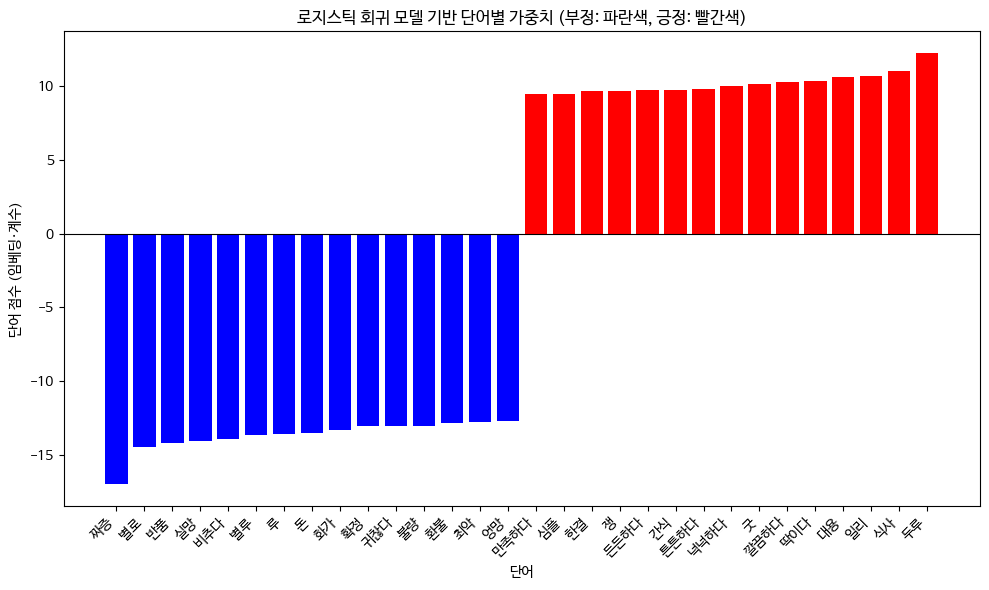

In [88]:
# 막대그래프 시각화

plt.figure(figsize=(10, 6))

# 막대의 색상: 음수는 빨간색, 양수는 파란색으로 설정
bar_colors = ['blue' if s < 0 else 'red' for s in scores]
plt.bar(range(len(words)), scores, color=bar_colors)

# y = 0 선 추가
plt.axhline(0, color = 'black', linewidth = 0.8)

# x축 눈금에 단어 표시, 회전하여 가독성 향상
plt.xticks(range(len(words)), words, rotation = 45, ha = "right")

# x축 레이블, y축 레이블
plt.xlabel("단어")
plt.ylabel("단어 점수 (임베딩·계수)")
plt.title("로지스틱 회귀 모델 기반 단어별 가중치 (부정: 파란색, 긍정: 빨간색)")

# 레이아웃 조정으로 요소들이 겹치지 않도록 함
plt.tight_layout()
plt.show()

## 결론 및 활용 방안

- <u><strong>모델 시각화</strong></u>를 통해 감성 분석에서 어떤 단어들이 긍정·부정 판단에 핵심적으로 작용하는지 직관적으로 파악 가능  
- 마케팅, 고객 만족도 조사, 상품 리뷰 모니터링 등에 적용할 때 인사이트 제공  

<br>

---

<br>

### 주의사항 및 추가 설명

> 1. <u><strong>맥락 의존성</strong></u>  
>    - 단어 자체가 무조건 긍정 혹은 부정이라 단정 짓기 어려움  
>    - 예: <font color="red">“배송이 빠르다” vs “배송이 늦다”</font>처럼 맥락에 따라 긍·부정이 달라짐  

> 2. <u><strong>단순 평균 벡터의 한계</strong></u>  
>    - 리뷰 전체 맥락을 100% 반영하기 어려움  
>    - <font color="red">TF-IDF 가중 평균, Doc2Vec, Sentence-BERT</font> 등 대안적 문서 임베딩 기법 고려  

> 3. <u><strong>로지스틱 회귀 모델</strong></u>  
>    - 선형(Linear) 모델로서 비선형적 특성을 반영하기 어려움  
>    - <font color="red">Random Forest, XGBoost, 딥러닝 기반 모델</font> 등 다른 접근과의 성능 비교 권장  

> 4. <u><strong>표본 편향 및 토큰 수 제한</strong></u>  
>    - <font color="red">min_count, window</font> 등 Word2Vec 파라미터 설정에 따라 결과가 달라질 수 있음  
>    - 리뷰 데이터 편향(특정 제품, 특정 표현만 다수)이 존재할 수 있음  

> 5. <u><strong>해석 시 참고</strong></u>  
>    - 내적 값이 매우 높거나 낮은 단어일수록 모델의 분류 결과에 강하게 작용  
>    - 실제 리뷰에서 해당 단어들이 많이 등장했는지, 특정 제품군에 치우친 것은 아닌지 점검 필요  

---

> **추가 개선**  
> - 특정 상품에 대한 만족과 불만족에 대한 인사이트 도출은 <font color="red">okt에서 명사추출</font>로 가능
> - 다른 임베딩 기법(<font color="red">BERT, fastText 등</font>)과의 비교 실험
> - 사용자 정의 사전(신조어, 전문용어)에 대한 보완  